# MA0218 Mini Proejct
## Team Data4Lives

#### Lab Group: 
MA6
#### TA:
Hasnain Ali
#### Dataset:
Aviation Accident Database
#### Team Members:
- Goh Kai Lun Brendon(U1920841H)
- Caleb Chan Yee Hang(U1821752G)
- Ho Wei How (U1821039B)

### Introduction
General Aviation is growing rapidly in the United States. As people fly between cities and states, unfortunate aviation accidents may occur. It is difficult to tell if there are survivors from the accident until search and rescue teams reach the location of the accident. When an accident occurs, authorities have to dispatch search and rescue teams as soon as possible to locate the accident and rescue survivors. Decisions regarding search and rescue have to be made, such as amount of manpower to deploy, working hours to search, whether the search and rescue efforts should continue through the night or through bad weather conditions, or when should the rescue efforts be called off. 

The intention is to generate a prediction model to predict if there are survivors or not from an accident, given certain known variables (such as weather etc.) as parameters for the model. This information could be useful for authorities to make decisions related to search and rescue efforts, as well as for the rescue team to be more prepared for what scenario they are likely to face upon locating the accident site. For example, if the model predicts that there are survivors from a flight, more resources should be injected to search and rescue the survivors as soon as possible, as survivors could turn into fatalities very quickly if aid is not rendered to them. 


In [1]:
import math
from collections import Counter
import numpy as np
import seaborn as sns
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import sklearn.preprocessing as sp
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from subprocess import check_output
from itertools import cycle, islice
from decimal import Decimal
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz
import graphviz
import matplotlib.pyplot as plt
import pydotplus
import matplotlib.image as mpimg
import io

### Import Dataset

In [2]:
# Import csv file
df = pd.read_csv('AviationData.csv', encoding = 'ANSI')
df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.Flight,Air.Carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight,Report.Status,Publication.Date
0,20200102X82407,Accident,WPR20CA055,2019-12-31,"Elk, CA",United States,39.128611,-123.715833,LLR,Little River,...,Personal,NaN,NaN,NaN,NaN,1.0,VMC,TAKEOFF,Factual,13-01-20
1,20191231X83852,Accident,CEN20FA049,2019-12-31,"OLATHE, KS",United States,38.846111,-94.736111,OJC,Johnson County Executive,...,Personal,NaN,2.0,NaN,NaN,NaN,VMC,TAKEOFF,Preliminary,08-01-20
2,20200102X54844,Accident,ANC20CA011,2019-12-31,"Fairbanks, AK",United States,64.666945,-148.133334,NaN,NaN,...,Personal,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Preliminary,02-01-20
3,20191230X91852,Accident,CEN20CA048,2019-12-30,"GRANBURY, TX",United States,32.365556,-97.645000,NaN,NaN,...,Personal,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Preliminary,31-12-19
4,20191228X62945,NaN,WPR20CA053,2019-12-28,"Missoula, MT",United States,NaN,NaN,MSO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Preliminary,03-01-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,NaN,VMC,APPROACH,Probable Cause,16-04-80
84258,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,CRUISE,Probable Cause,12-09-00
84259,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,CRUISE,Probable Cause,26-02-07
84260,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,UNKNOWN,Probable Cause,19-09-96


### Preparing the Dataset 
- Remove Unwanted variables
- Convert float to strings
- Convert strings to uppercase
- Fill up NaN values
- Remove all non-Airplane data
- Create new Fatal Bool which is the response variable to predict

In [3]:
# Remove unwanted columns
df = df.drop(['Event.Id','Investigation.Type','Accident.Number','Location','Airport.Code','Airport.Name','Injury.Severity','Aircraft.Damage','Registration.Number','Model','FAR.Description','Schedule','Purpose.of.Flight','Air.Carrier','Report.Status','Publication.Date'], axis = 1)
df

,Event.Date,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight
0,2019-12-31,United States,39.128611,-123.715833,Airplane,Cessna,No,1.0,Reciprocating,NaN,NaN,NaN,1.0,VMC,TAKEOFF
1,2019-12-31,United States,38.846111,-94.736111,Airplane,Mooney,No,1.0,Reciprocating,2.0,NaN,NaN,NaN,VMC,TAKEOFF
2,2019-12-31,United States,64.666945,-148.133334,Airplane,Cessna,No,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN
3,2019-12-30,United States,32.365556,-97.645000,Airplane,Vans,Yes,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,2019-12-28,United States,NaN,NaN,NaN,Cessna,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979-08-02,United States,NaN,NaN,NaN,Cessna,No,NaN,NaN,1.0,2.0,NaN,NaN,VMC,APPROACH
84258,1977-06-19,United States,NaN,NaN,NaN,Rockwell,No,1.0,Reciprocating,2.0,0.0,0.0,0.0,IMC,CRUISE
84259,1974-08-30,United States,36.922223,-81.878056,NaN,Cessna,No,1.0,Reciprocating,3.0,NaN,NaN,NaN,IMC,CRUISE
84260,1962-07-19,United States,NaN,NaN,NaN,PIPER,No,1.0,Reciprocating,4.0,0.0,0.0,0.0,UNK,UNKNOWN


In [4]:
# Converting 'Event.Date' to 'Event.Year' because the day and month is not important
# Removed the 'Event.Date' column since it is no longer required
EventYear = pd.DatetimeIndex(df['Event.Date']).year
df.insert(0, 'Event.Year', EventYear, True)
df

,Event.Year,Event.Date,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight
0,2019,2019-12-31,United States,39.128611,-123.715833,Airplane,Cessna,No,1.0,Reciprocating,NaN,NaN,NaN,1.0,VMC,TAKEOFF
1,2019,2019-12-31,United States,38.846111,-94.736111,Airplane,Mooney,No,1.0,Reciprocating,2.0,NaN,NaN,NaN,VMC,TAKEOFF
2,2019,2019-12-31,United States,64.666945,-148.133334,Airplane,Cessna,No,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN
3,2019,2019-12-30,United States,32.365556,-97.645000,Airplane,Vans,Yes,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,2019,2019-12-28,United States,NaN,NaN,NaN,Cessna,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,1979-08-02,United States,NaN,NaN,NaN,Cessna,No,NaN,NaN,1.0,2.0,NaN,NaN,VMC,APPROACH
84258,1977,1977-06-19,United States,NaN,NaN,NaN,Rockwell,No,1.0,Reciprocating,2.0,0.0,0.0,0.0,IMC,CRUISE
84259,1974,1974-08-30,United States,36.922223,-81.878056,NaN,Cessna,No,1.0,Reciprocating,3.0,NaN,NaN,NaN,IMC,CRUISE
84260,1962,1962-07-19,United States,NaN,NaN,NaN,PIPER,No,1.0,Reciprocating,4.0,0.0,0.0,0.0,UNK,UNKNOWN


In [5]:
# Remove 'Event.Date' column as it is no longer required
df = df.drop(['Event.Date'], axis = 1)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight
0,2019,United States,39.128611,-123.715833,Airplane,Cessna,No,1.0,Reciprocating,NaN,NaN,NaN,1.0,VMC,TAKEOFF
1,2019,United States,38.846111,-94.736111,Airplane,Mooney,No,1.0,Reciprocating,2.0,NaN,NaN,NaN,VMC,TAKEOFF
2,2019,United States,64.666945,-148.133334,Airplane,Cessna,No,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN
3,2019,United States,32.365556,-97.645000,Airplane,Vans,Yes,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,2019,United States,NaN,NaN,NaN,Cessna,No,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,United States,NaN,NaN,NaN,Cessna,No,NaN,NaN,1.0,2.0,NaN,NaN,VMC,APPROACH
84258,1977,United States,NaN,NaN,NaN,Rockwell,No,1.0,Reciprocating,2.0,0.0,0.0,0.0,IMC,CRUISE
84259,1974,United States,36.922223,-81.878056,NaN,Cessna,No,1.0,Reciprocating,3.0,NaN,NaN,NaN,IMC,CRUISE
84260,1962,United States,NaN,NaN,NaN,PIPER,No,1.0,Reciprocating,4.0,0.0,0.0,0.0,UNK,UNKNOWN


In [6]:
# Convert strings to upper case because some data is in smaller case letters while others are in upper case letters
df['Country'] = df['Country'].str.upper()
df['Aircraft.Category'] = df['Aircraft.Category'].str.upper()
df['Make'] = df['Make'].str.upper()
df['Amateur.Built'] = df['Amateur.Built'].str.upper()
df['Engine.Type'] = df['Engine.Type'].str.upper()
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,CESSNA,NO,1.0,RECIPROCATING,NaN,NaN,NaN,1.0,VMC,TAKEOFF
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,MOONEY,NO,1.0,RECIPROCATING,2.0,NaN,NaN,NaN,VMC,TAKEOFF
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,CESSNA,NO,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN
3,2019,UNITED STATES,32.365556,-97.645000,AIRPLANE,VANS,YES,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,2019,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,NaN,NaN,1.0,2.0,NaN,NaN,VMC,APPROACH
84258,1977,UNITED STATES,NaN,NaN,NaN,ROCKWELL,NO,1.0,RECIPROCATING,2.0,0.0,0.0,0.0,IMC,CRUISE
84259,1974,UNITED STATES,36.922223,-81.878056,NaN,CESSNA,NO,1.0,RECIPROCATING,3.0,NaN,NaN,NaN,IMC,CRUISE
84260,1962,UNITED STATES,NaN,NaN,NaN,PIPER,NO,1.0,RECIPROCATING,4.0,0.0,0.0,0.0,UNK,UNKNOWN


In [7]:
# Fill up NaN values with 0 value in columns listed below
df['Total.Fatal.Injuries'] = df['Total.Fatal.Injuries'].fillna(0)
df['Total.Serious.Injuries'] = df['Total.Serious.Injuries'].fillna(0)
df['Total.Minor.Injuries'] = df['Total.Minor.Injuries'].fillna(0)
df['Total.Uninjured'] = df['Total.Uninjured'].fillna(0)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,CESSNA,NO,1.0,RECIPROCATING,0.0,0.0,0.0,1.0,VMC,TAKEOFF
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,MOONEY,NO,1.0,RECIPROCATING,2.0,0.0,0.0,0.0,VMC,TAKEOFF
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,CESSNA,NO,1.0,NaN,0.0,0.0,0.0,2.0,NaN,NaN
3,2019,UNITED STATES,32.365556,-97.645000,AIRPLANE,VANS,YES,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN
4,2019,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,1.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,NaN,NaN,1.0,2.0,0.0,0.0,VMC,APPROACH
84258,1977,UNITED STATES,NaN,NaN,NaN,ROCKWELL,NO,1.0,RECIPROCATING,2.0,0.0,0.0,0.0,IMC,CRUISE
84259,1974,UNITED STATES,36.922223,-81.878056,NaN,CESSNA,NO,1.0,RECIPROCATING,3.0,0.0,0.0,0.0,IMC,CRUISE
84260,1962,UNITED STATES,NaN,NaN,NaN,PIPER,NO,1.0,RECIPROCATING,4.0,0.0,0.0,0.0,UNK,UNKNOWN


In [8]:
# Convert columns below from float to string
df['Total.Fatal.Injuries'] = df['Total.Fatal.Injuries'].astype(str)
df['Total.Serious.Injuries'] = df['Total.Serious.Injuries'].astype(str)
df['Total.Minor.Injuries'] = df['Total.Minor.Injuries'].astype(str)
df['Total.Uninjured'] = df['Total.Uninjured'].astype(str)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,CESSNA,NO,1.0,RECIPROCATING,0.0,0.0,0.0,1.0,VMC,TAKEOFF
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,MOONEY,NO,1.0,RECIPROCATING,2.0,0.0,0.0,0.0,VMC,TAKEOFF
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,CESSNA,NO,1.0,NaN,0.0,0.0,0.0,2.0,NaN,NaN
3,2019,UNITED STATES,32.365556,-97.645000,AIRPLANE,VANS,YES,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN
4,2019,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,1.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,NaN,NaN,1.0,2.0,0.0,0.0,VMC,APPROACH
84258,1977,UNITED STATES,NaN,NaN,NaN,ROCKWELL,NO,1.0,RECIPROCATING,2.0,0.0,0.0,0.0,IMC,CRUISE
84259,1974,UNITED STATES,36.922223,-81.878056,NaN,CESSNA,NO,1.0,RECIPROCATING,3.0,0.0,0.0,0.0,IMC,CRUISE
84260,1962,UNITED STATES,NaN,NaN,NaN,PIPER,NO,1.0,RECIPROCATING,4.0,0.0,0.0,0.0,UNK,UNKNOWN


In [9]:
# Forming a new column, '100% Fatal.Bool'
# TRUE means all the passengers died in the accident, FALSE means otherwise
fatal_bool = []
for i in range(len(df)):
    fatal_resp1 = df.iloc[i]['Total.Fatal.Injuries']
    fatal_resp2 = df.iloc[i]['Total.Serious.Injuries']
    fatal_resp3 = df.iloc[i]['Total.Minor.Injuries']
    fatal_resp4 = df.iloc[i]['Total.Uninjured']    
    if str(fatal_resp1) != '0.0' and str(fatal_resp2) == '0.0' and str(fatal_resp3) == '0.0' and str(fatal_resp4) == '0.0':
        fatal_bool.append("TRUE")
    else:
        fatal_bool.append("FALSE")
df['100% Fatal.Bool'] = fatal_bool
df.insert(8, '100% Fatal.Bool', fatal_bool, True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight,100% Fatal.Bool
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,CESSNA,NO,1.0,FALSE,RECIPROCATING,0.0,0.0,0.0,1.0,VMC,TAKEOFF,FALSE
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,MOONEY,NO,1.0,TRUE,RECIPROCATING,2.0,0.0,0.0,0.0,VMC,TAKEOFF,TRUE
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,CESSNA,NO,1.0,FALSE,NaN,0.0,0.0,0.0,2.0,NaN,NaN,FALSE
3,2019,UNITED STATES,32.365556,-97.645000,AIRPLANE,VANS,YES,NaN,FALSE,NaN,0.0,0.0,0.0,1.0,NaN,NaN,FALSE
4,2019,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,1.0,FALSE,NaN,0.0,0.0,0.0,0.0,NaN,NaN,FALSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,NaN,FALSE,NaN,1.0,2.0,0.0,0.0,VMC,APPROACH,FALSE
84258,1977,UNITED STATES,NaN,NaN,NaN,ROCKWELL,NO,1.0,TRUE,RECIPROCATING,2.0,0.0,0.0,0.0,IMC,CRUISE,TRUE
84259,1974,UNITED STATES,36.922223,-81.878056,NaN,CESSNA,NO,1.0,TRUE,RECIPROCATING,3.0,0.0,0.0,0.0,IMC,CRUISE,TRUE
84260,1962,UNITED STATES,NaN,NaN,NaN,PIPER,NO,1.0,TRUE,RECIPROCATING,4.0,0.0,0.0,0.0,UNK,UNKNOWN,TRUE


In [10]:
# Removing the duplicated 'Fatal.Bool' column and the 'Injury Severity' column
df = df.loc[:,~df.columns.duplicated()]
df = df.drop(['Total.Fatal.Injuries','Total.Serious.Injuries','Total.Minor.Injuries','Total.Uninjured'], axis = 1)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,CESSNA,NO,1.0,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,MOONEY,NO,1.0,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,CESSNA,NO,1.0,FALSE,NaN,NaN,NaN
3,2019,UNITED STATES,32.365556,-97.645000,AIRPLANE,VANS,YES,NaN,FALSE,NaN,NaN,NaN
4,2019,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,1.0,FALSE,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,NaN,CESSNA,NO,NaN,FALSE,NaN,VMC,APPROACH
84258,1977,UNITED STATES,NaN,NaN,NaN,ROCKWELL,NO,1.0,TRUE,RECIPROCATING,IMC,CRUISE
84259,1974,UNITED STATES,36.922223,-81.878056,NaN,CESSNA,NO,1.0,TRUE,RECIPROCATING,IMC,CRUISE
84260,1962,UNITED STATES,NaN,NaN,NaN,PIPER,NO,1.0,TRUE,RECIPROCATING,UNK,UNKNOWN


In [11]:
# Forming a new column, 'Aircraft.Type'
aircraft_type = []
for i in range(len(df)):
    type_resp = df.iloc[i]['Make']
    if str(type_resp) == 'CESSNA' or str(type_resp) == 'MOONEY' or str(type_resp) == 'PIPER' or str(type_resp) == 'BEECH' or str(type_resp) == 'BOEING':
        aircraft_type.append("AIRPLANE")
    else:
        aircraft_type.append("NOT AIRPLANE")
df['Aircraft.Type'] = aircraft_type
df.insert(4, 'Aircraft.Type', aircraft_type , True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Aircraft.Category,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight,Aircraft.Type
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,AIRPLANE,CESSNA,NO,1.0,FALSE,RECIPROCATING,VMC,TAKEOFF,AIRPLANE
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,AIRPLANE,MOONEY,NO,1.0,TRUE,RECIPROCATING,VMC,TAKEOFF,AIRPLANE
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,AIRPLANE,CESSNA,NO,1.0,FALSE,NaN,NaN,NaN,AIRPLANE
3,2019,UNITED STATES,32.365556,-97.645000,NOT AIRPLANE,AIRPLANE,VANS,YES,NaN,FALSE,NaN,NaN,NaN,NOT AIRPLANE
4,2019,UNITED STATES,NaN,NaN,AIRPLANE,NaN,CESSNA,NO,1.0,FALSE,NaN,NaN,NaN,AIRPLANE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,AIRPLANE,NaN,CESSNA,NO,NaN,FALSE,NaN,VMC,APPROACH,AIRPLANE
84258,1977,UNITED STATES,NaN,NaN,NOT AIRPLANE,NaN,ROCKWELL,NO,1.0,TRUE,RECIPROCATING,IMC,CRUISE,NOT AIRPLANE
84259,1974,UNITED STATES,36.922223,-81.878056,AIRPLANE,NaN,CESSNA,NO,1.0,TRUE,RECIPROCATING,IMC,CRUISE,AIRPLANE
84260,1962,UNITED STATES,NaN,NaN,AIRPLANE,NaN,PIPER,NO,1.0,TRUE,RECIPROCATING,UNK,UNKNOWN,AIRPLANE


In [12]:
# Removing the duplicated 'Aircraft.Type' column and the 'Aircraft.Category' column
df = df.loc[:,~df.columns.duplicated()]
df = df.drop(['Aircraft.Category'], axis = 1)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.128611,-123.715833,AIRPLANE,CESSNA,NO,1.0,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.846111,-94.736111,AIRPLANE,MOONEY,NO,1.0,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.666945,-148.133334,AIRPLANE,CESSNA,NO,1.0,FALSE,NaN,NaN,NaN
3,2019,UNITED STATES,32.365556,-97.645000,NOT AIRPLANE,VANS,YES,NaN,FALSE,NaN,NaN,NaN
4,2019,UNITED STATES,NaN,NaN,AIRPLANE,CESSNA,NO,1.0,FALSE,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,NaN,NaN,AIRPLANE,CESSNA,NO,NaN,FALSE,NaN,VMC,APPROACH
84258,1977,UNITED STATES,NaN,NaN,NOT AIRPLANE,ROCKWELL,NO,1.0,TRUE,RECIPROCATING,IMC,CRUISE
84259,1974,UNITED STATES,36.922223,-81.878056,AIRPLANE,CESSNA,NO,1.0,TRUE,RECIPROCATING,IMC,CRUISE
84260,1962,UNITED STATES,NaN,NaN,AIRPLANE,PIPER,NO,1.0,TRUE,RECIPROCATING,UNK,UNKNOWN


In [13]:
# Replacing all NaN responses with a blank string
df = df.replace(np.nan, '', regex = True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.6669,-148.133,AIRPLANE,CESSNA,NO,1,FALSE,,,
3,2019,UNITED STATES,32.3656,-97.645,NOT AIRPLANE,VANS,YES,,FALSE,,,
4,2019,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,,,
...,...,...,...,...,...,...,...,...,...,...,...,...
84257,1979,UNITED STATES,,,AIRPLANE,CESSNA,NO,,FALSE,,VMC,APPROACH
84258,1977,UNITED STATES,,,NOT AIRPLANE,ROCKWELL,NO,1,TRUE,RECIPROCATING,IMC,CRUISE
84259,1974,UNITED STATES,36.9222,-81.8781,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE
84260,1962,UNITED STATES,,,AIRPLANE,PIPER,NO,1,TRUE,RECIPROCATING,UNK,UNKNOWN


In [14]:
# Checking the unique responses in 'Country' column
df['Country'].value_counts(sort = True)

UNITED STATES    78849
                   507
CANADA             308
BRAZIL             291
MEXICO             269
                 ...  
LAOS                 1
COMOROS              1
CAMBODIA             1
IVORY COAST          1
NEW CALEDONIA        1
Name: Country, Length: 180, dtype: int64

In [15]:
# Removing all responses except 'UNITED STATES' from the 'Country' column
df = df[df['Country'].str.match('UNITED STATES')]
df.reset_index(inplace = True, drop = True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.6669,-148.133,AIRPLANE,CESSNA,NO,1,FALSE,,,
3,2019,UNITED STATES,32.3656,-97.645,NOT AIRPLANE,VANS,YES,,FALSE,,,
4,2019,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,,,
...,...,...,...,...,...,...,...,...,...,...,...,...
78844,1979,UNITED STATES,,,AIRPLANE,CESSNA,NO,,FALSE,,VMC,APPROACH
78845,1977,UNITED STATES,,,NOT AIRPLANE,ROCKWELL,NO,1,TRUE,RECIPROCATING,IMC,CRUISE
78846,1974,UNITED STATES,36.9222,-81.8781,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE
78847,1962,UNITED STATES,,,AIRPLANE,PIPER,NO,1,TRUE,RECIPROCATING,UNK,UNKNOWN


In [16]:
# Checking the unique responses in 'Country' column
df['Country'].value_counts(sort = True)

UNITED STATES    78849
Name: Country, dtype: int64

In [17]:
# Checking the unique responses in 'Aircraft.Type' column
df['Aircraft.Type'].value_counts(sort = True)

AIRPLANE        46192
NOT AIRPLANE    32657
Name: Aircraft.Type, dtype: int64

In [18]:
# Removing 'NOT AIRPLANE' response in 'Aircraft.Type' column
df = df[df['Aircraft.Type'].str.match('AIRPLANE')]
df.reset_index(inplace = True, drop = True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.6669,-148.133,AIRPLANE,CESSNA,NO,1,FALSE,,,
3,2019,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,,,
4,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
...,...,...,...,...,...,...,...,...,...,...,...,...
46187,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING
46188,1981,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,UNKNOWN
46189,1979,UNITED STATES,,,AIRPLANE,CESSNA,NO,,FALSE,,VMC,APPROACH
46190,1974,UNITED STATES,36.9222,-81.8781,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE


In [19]:
# Checking the unique responses in 'Aircraft.Type' column
df['Aircraft.Type'].value_counts(sort = True)

AIRPLANE    46192
Name: Aircraft.Type, dtype: int64

In [20]:
# Checking the unique responses in 'Make' column
df['Make'].value_counts(sort = True)

CESSNA    25003
PIPER     13640
BEECH      4879
BOEING     1428
MOONEY     1242
Name: Make, dtype: int64

In [21]:
# Checking the unique responses in 'Weather.Condition' column
df['Amateur.Built'].value_counts(sort = True)

NO     46003
YES      140
          49
Name: Amateur.Built, dtype: int64

In [22]:
# Removing '' and UNK' responses in 'Weather.Condition' column
AmateurBuilt = df['Amateur.Built']
df = df[AmateurBuilt != '']
df.reset_index(inplace = True, drop = True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.6669,-148.133,AIRPLANE,CESSNA,NO,1,FALSE,,,
3,2019,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,,,
4,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
...,...,...,...,...,...,...,...,...,...,...,...,...
46138,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING
46139,1981,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,UNKNOWN
46140,1979,UNITED STATES,,,AIRPLANE,CESSNA,NO,,FALSE,,VMC,APPROACH
46141,1974,UNITED STATES,36.9222,-81.8781,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE


In [23]:
# Checking the unique responses in 'Weather.Condition' column
df['Amateur.Built'].value_counts(sort = True)

NO     46003
YES      140
Name: Amateur.Built, dtype: int64

In [24]:
# Checking the unique responses in 'Weather.Condition' column
df['Number.of.Engines'].value_counts(sort = True)

1.0    38870
2.0     6547
         305
3.0      241
4.0      156
0.0       24
Name: Number.of.Engines, dtype: int64

In [25]:
# Removing '' and UNK' responses in 'Weather.Condition' column
NumberofEngines = df['Number.of.Engines']
df = df[NumberofEngines != '']
df = df[NumberofEngines != '0.0']
df.reset_index(inplace = True, drop = True)
df

C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.


,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,64.6669,-148.133,AIRPLANE,CESSNA,NO,1,FALSE,,,
3,2019,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,,,
4,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
...,...,...,...,...,...,...,...,...,...,...,...,...
45833,1982,UNITED STATES,,,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,APPROACH
45834,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING
45835,1981,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,UNKNOWN
45836,1974,UNITED STATES,36.9222,-81.8781,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE


In [26]:
# Checking the unique responses in 'Weather.Condition' column
df['Number.of.Engines'].value_counts(sort = True)

1.0    38870
2.0     6547
3.0      241
4.0      156
0.0       24
Name: Number.of.Engines, dtype: int64

In [27]:
# Checking the unique responses in 'FataL.Bool' column
df['100% Fatal.Bool'].value_counts(sort = True)

FALSE    39124
TRUE      6714
Name: 100% Fatal.Bool, dtype: int64

In [28]:
# Checking the unique responses in 'Weather.Condition' column
df['Engine.Type'].value_counts(sort = True)

RECIPROCATING    43466
TURBO PROP        1008
TURBO FAN          944
TURBO JET          227
                   136
UNKNOWN             46
TURBO SHAFT         11
Name: Engine.Type, dtype: int64

In [29]:
# Removing '' and UNK' responses in 'Weather.Condition' column
EngineType = df['Engine.Type']
df = df[EngineType != '']
df = df[EngineType != 'UNKNOWN']
df.reset_index(inplace = True, drop = True)
df

C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.


,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
3,2019,UNITED STATES,38.0958,-87.5406,AIRPLANE,PIPER,NO,1,TRUE,RECIPROCATING,,APPROACH
4,2019,UNITED STATES,43.6439,-116.637,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,
...,...,...,...,...,...,...,...,...,...,...,...,...
45651,1982,UNITED STATES,,,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,APPROACH
45652,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING
45653,1981,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,UNKNOWN
45654,1974,UNITED STATES,36.9222,-81.8781,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE


In [30]:
# Checking the unique responses in 'Weather.Condition' column
df['Engine.Type'].value_counts(sort = True)

RECIPROCATING    43466
TURBO PROP        1008
TURBO FAN          944
TURBO JET          227
TURBO SHAFT         11
Name: Engine.Type, dtype: int64

In [31]:
# Checking the unique responses in 'Weather.Condition' column
df['Weather.Condition'].value_counts(sort = True)

VMC    41024
IMC     4092
UNK      410
         130
Name: Weather.Condition, dtype: int64

In [32]:
# Removing '' and UNK' responses in 'Weather.Condition' column
WeatherCondition = df['Weather.Condition']
df = df[WeatherCondition != '']
df = df[WeatherCondition != 'UNK']
df.reset_index(inplace = True, drop = True)
df

C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.


,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
3,2019,UNITED STATES,43.6439,-116.637,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,
4,2019,UNITED STATES,39.2592,-84.7744,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,LANDING
...,...,...,...,...,...,...,...,...,...,...,...,...
45111,1982,UNITED STATES,,,AIRPLANE,CESSNA,NO,2,FALSE,RECIPROCATING,IMC,LANDING
45112,1982,UNITED STATES,,,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,APPROACH
45113,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING
45114,1981,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,UNKNOWN


In [33]:
# Checking the unique responses in 'Weather.Condition' column
df['Weather.Condition'].value_counts(sort = True)

VMC    41024
IMC     4092
Name: Weather.Condition, dtype: int64

In [34]:
# Checking the unique responses in 'Broad.Phase.of.Flight' column
df['Broad.Phase.of.Flight'].value_counts(sort = True)

LANDING        13105
TAKEOFF         8951
CRUISE          6656
APPROACH        4915
MANEUVERING     3665
TAXI            1603
DESCENT         1409
CLIMB           1406
GO-AROUND       1260
                1165
STANDING         642
UNKNOWN          277
OTHER             62
Name: Broad.Phase.of.Flight, dtype: int64

In [35]:
# Remove '', UNKNOWN' and 'OTHER' response in 'Broad.Phase.of.Flight' column
BPOF = df['Broad.Phase.of.Flight']
df = df[BPOF != '']
df = df[BPOF != 'UNKNOWN']
df = df[BPOF != 'OTHER']
df.reset_index(inplace = True, drop = True)
df

C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.
C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """


,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
3,2019,UNITED STATES,39.2592,-84.7744,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,LANDING
4,2019,UNITED STATES,33.1464,-117.334,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,CRUISE
...,...,...,...,...,...,...,...,...,...,...,...,...
43607,1982,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
43608,1982,UNITED STATES,,,AIRPLANE,CESSNA,NO,2,FALSE,RECIPROCATING,IMC,LANDING
43609,1982,UNITED STATES,,,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,APPROACH
43610,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING


In [36]:
# Checking the unique responses in 'Broad.Phase.of.Flight' column
df['Broad.Phase.of.Flight'].value_counts(sort = True)

LANDING        13105
TAKEOFF         8951
CRUISE          6656
APPROACH        4915
MANEUVERING     3665
TAXI            1603
DESCENT         1409
CLIMB           1406
GO-AROUND       1260
STANDING         642
Name: Broad.Phase.of.Flight, dtype: int64

In [37]:
# Reset index for df dataframe
df.reset_index(drop = True, inplace = True)
df

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
3,2019,UNITED STATES,39.2592,-84.7744,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,LANDING
4,2019,UNITED STATES,33.1464,-117.334,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,CRUISE
...,...,...,...,...,...,...,...,...,...,...,...,...
43607,1982,UNITED STATES,,,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
43608,1982,UNITED STATES,,,AIRPLANE,CESSNA,NO,2,FALSE,RECIPROCATING,IMC,LANDING
43609,1982,UNITED STATES,,,AIRPLANE,PIPER,NO,1,FALSE,RECIPROCATING,VMC,APPROACH
43610,1982,UNITED STATES,,,AIRPLANE,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING


### Exploratory Data Analysis
Study the following variables as predictors:
- Accident Location
- Aircraft Make
- Amateur Built
- Number of Engine
- Engine Type
- Weather Condition
- Broad Phase of Flight

In [38]:
# Removing '' in 'Latitude' and 'Longitude' columns and saving it as a new dataframe, df2
# Only used for plotting the map
Lat = df['Latitude']
df2 = df[Lat != '']
Lon = df['Longitude']
df2 = df[Lon != '']
df2.reset_index(drop = True, inplace = True)
df2

,Event.Year,Country,Latitude,Longitude,Aircraft.Type,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,2019,UNITED STATES,39.1286,-123.716,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,2019,UNITED STATES,38.8461,-94.7361,AIRPLANE,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,2019,UNITED STATES,30.1761,-92.0075,AIRPLANE,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
3,2019,UNITED STATES,39.2592,-84.7744,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,LANDING
4,2019,UNITED STATES,33.1464,-117.334,AIRPLANE,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,CRUISE
...,...,...,...,...,...,...,...,...,...,...,...,...
12700,1998,UNITED STATES,29.6072,-95.1586,AIRPLANE,BOEING,NO,2,FALSE,TURBO JET,IMC,APPROACH
12701,1995,UNITED STATES,38.335,-80.28,AIRPLANE,CESSNA,NO,2,TRUE,RECIPROCATING,IMC,CRUISE
12702,1983,UNITED STATES,48.12,-113.888,AIRPLANE,CESSNA,NO,1,TRUE,RECIPROCATING,IMC,CRUISE
12703,1982,UNITED STATES,30.7578,-88.3556,AIRPLANE,BEECH,NO,1,TRUE,RECIPROCATING,IMC,LANDING


In [39]:
# Plotting the map showing accident locations using 'Latitude' & 'Longitude' data from df2
import folium
subset_df2 = df2[['Event.Year', 'Latitude', 'Longitude', '100% Fatal.Bool']]
subset_df2['Event.Year'] = subset_df2['Event.Year'].astype(int)
recent = subset_df2[subset_df2['Event.Year'] >= 2019]
recent.reset_index(inplace = True)
m = folium.Map(location =[40,-90], zoom_start = 1)
for i in range(len(recent)):
    lon = recent.iloc[i]['Longitude']
    lat = recent.iloc[i]['Latitude']
    year = recent.iloc[i]['Event.Year']
    fatal = recent.iloc[i]['100% Fatal.Bool']
    if fatal == "TRUE":
        folium.Marker([lat, lon], icon = folium.Icon(color = 'red', icon = 'frown-o', prefix = 'fa')).add_to(m)
    else: 
        folium.Marker([lat, lon], icon = folium.Icon(color = 'green', icon = 'smile-o', prefix = 'fa')).add_to(m)
m.save('map.html')     

C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


In [40]:
# Drop columns 'Latitude' and 'Longitude' from df
df = df.drop(['Event.Year','Latitude', 'Longitude','Country','Aircraft.Type'], axis = 1)
df

,Make,Amateur.Built,Number.of.Engines,100% Fatal.Bool,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
1,MOONEY,NO,1,TRUE,RECIPROCATING,VMC,TAKEOFF
2,PIPER,NO,2,FALSE,TURBO PROP,IMC,TAKEOFF
3,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,LANDING
4,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,CRUISE
...,...,...,...,...,...,...,...
43607,CESSNA,NO,1,FALSE,RECIPROCATING,VMC,TAKEOFF
43608,CESSNA,NO,2,FALSE,RECIPROCATING,IMC,LANDING
43609,PIPER,NO,1,FALSE,RECIPROCATING,VMC,APPROACH
43610,BEECH,NO,1,FALSE,RECIPROCATING,VMC,LANDING


In [41]:
ct1 = pd.crosstab(df['Make'], df['100% Fatal.Bool'])
ct1

100% Fatal.Bool,FALSE,TRUE
Make,,
BEECH,3525,1045
BOEING,1211,23
CESSNA,21019,2735
MOONEY,899,268
PIPER,10907,1980


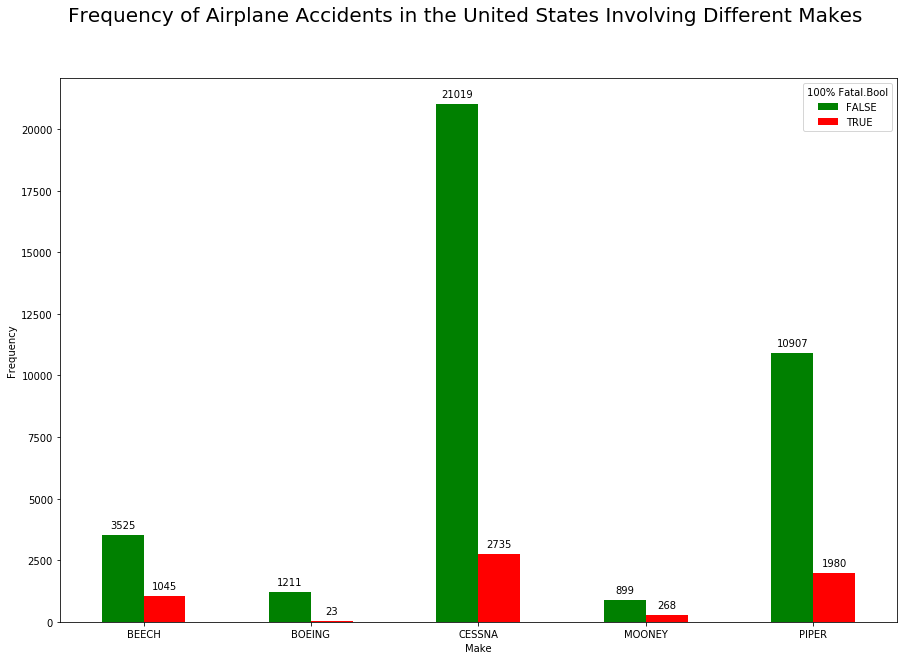

In [42]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct1.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Make', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Frequency', fontsize = 10)
plt.suptitle('Frequency of Airplane Accidents in the United States Involving Different Makes', fontsize = 20)
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

In [43]:
TA = (ct1['FALSE'] + ct1['TRUE'])
ct1.insert(2,'TOTAL ACCIDENTS', TA)
ct1

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS
Make,,,
BEECH,3525,1045,4570
BOEING,1211,23,1234
CESSNA,21019,2735,23754
MOONEY,899,268,1167
PIPER,10907,1980,12887


In [44]:
# Caclulating the Percentage Fatalities and Non-Fatalities for ct1
PercentageFalse = (100*ct1['FALSE']) / (ct1['TOTAL ACCIDENTS'])
ct1.insert(3, 'PERCENTAGE FALSE', PercentageFalse, True)
PercentageTrue = (100*ct1['TRUE']) / (ct1['TOTAL ACCIDENTS'])
ct1.insert(4, 'PERCENTAGE TRUE', PercentageTrue, True)
ct1 = ct1.round({'PERCENTAGE FALSE': 1, 'PERCENTAGE TRUE': 1})
ct1

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS,PERCENTAGE FALSE,PERCENTAGE TRUE
Make,,,,,
BEECH,3525,1045,4570,77.1,22.9
BOEING,1211,23,1234,98.1,1.9
CESSNA,21019,2735,23754,88.5,11.5
MOONEY,899,268,1167,77.0,23.0
PIPER,10907,1980,12887,84.6,15.4


In [45]:
ct2 = ct1[['PERCENTAGE FALSE', 'PERCENTAGE TRUE']].copy()
ct2

100% Fatal.Bool,PERCENTAGE FALSE,PERCENTAGE TRUE
Make,,
BEECH,77.1,22.9
BOEING,98.1,1.9
CESSNA,88.5,11.5
MOONEY,77.0,23.0
PIPER,84.6,15.4


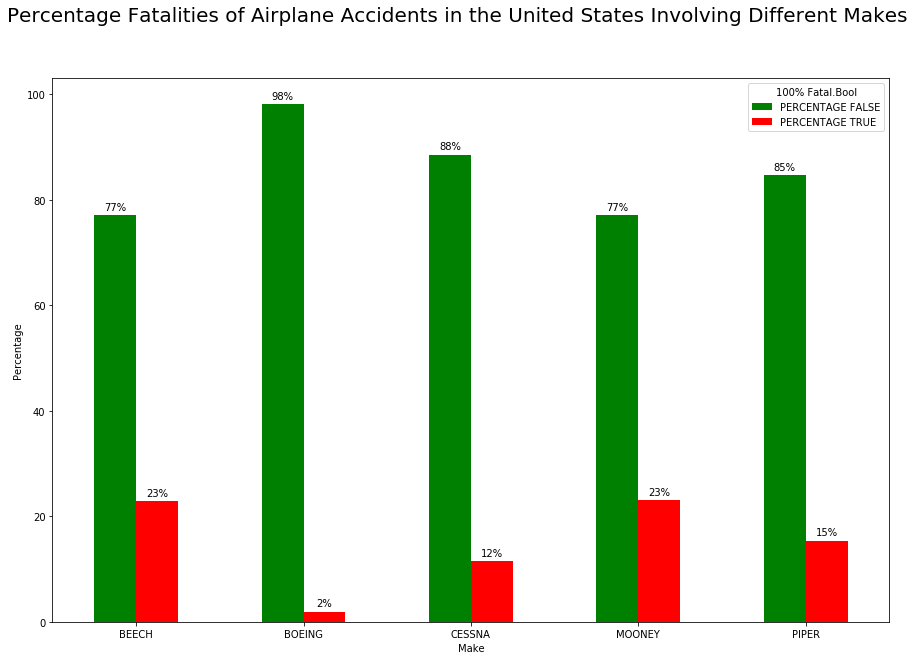

In [46]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct2.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Make', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Percentage', fontsize = 10)
plt.suptitle('Percentage Fatalities of Airplane Accidents in the United States Involving Different Makes', fontsize = 20)
bars = ax.patches
half = int(len(bars)/2)
left_bars = bars[:half]
right_bars = bars[half:]
for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total = height_l + height_r
        ax.text(left.get_x() + left.get_width()/2., height_l + 1, '{0:.0%}'.format(height_l/total), ha = "center")
        ax.text(right.get_x() + right.get_width()/2., height_r + 1, '{0:.0%}'.format(height_r/total), ha = "center")

In [47]:
ct3 = pd.crosstab(df['Amateur.Built'], df['100% Fatal.Bool'])
ct3

100% Fatal.Bool,FALSE,TRUE
Amateur.Built,,
NO,37460,6028
YES,101,23


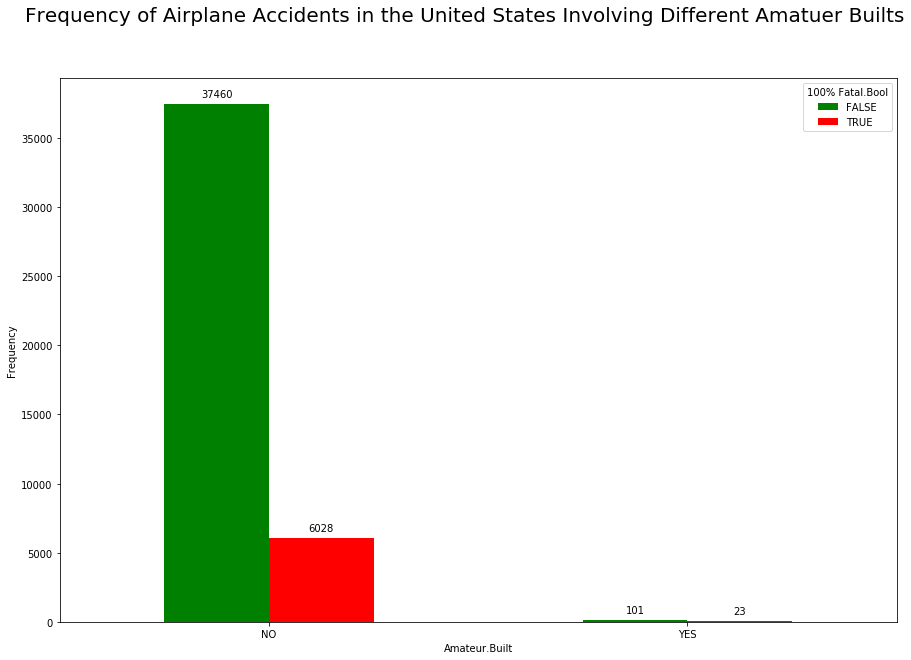

In [48]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct3.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Amateur.Built', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Frequency', fontsize = 10)
plt.suptitle('Frequency of Airplane Accidents in the United States Involving Different Amatuer Builts', fontsize = 20)
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

In [49]:
TA = (ct3['FALSE'] + ct3['TRUE'])
ct3.insert(2,'TOTAL ACCIDENTS', TA)
ct3

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS
Amateur.Built,,,
NO,37460,6028,43488
YES,101,23,124


In [50]:
# Caclulating the Percentage Fatalities and Non-Fatalities for ct3
PercentageFalse = (100*ct3['FALSE']) / (ct3['TOTAL ACCIDENTS'])
ct3.insert(3, 'PERCENTAGE FALSE', PercentageFalse, True)
PercentageTrue = (100*ct3['TRUE']) / (ct3['TOTAL ACCIDENTS'])
ct3.insert(4, 'PERCENTAGE TRUE', PercentageTrue, True)
ct3 = ct3.round({'PERCENTAGE FALSE': 1, 'PERCENTAGE TRUE': 1})
ct3

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS,PERCENTAGE FALSE,PERCENTAGE TRUE
Amateur.Built,,,,,
NO,37460,6028,43488,86.1,13.9
YES,101,23,124,81.5,18.5


In [51]:
ct4 = ct3[['PERCENTAGE FALSE', 'PERCENTAGE TRUE']].copy()
ct4

100% Fatal.Bool,PERCENTAGE FALSE,PERCENTAGE TRUE
Amateur.Built,,
NO,86.1,13.9
YES,81.5,18.5


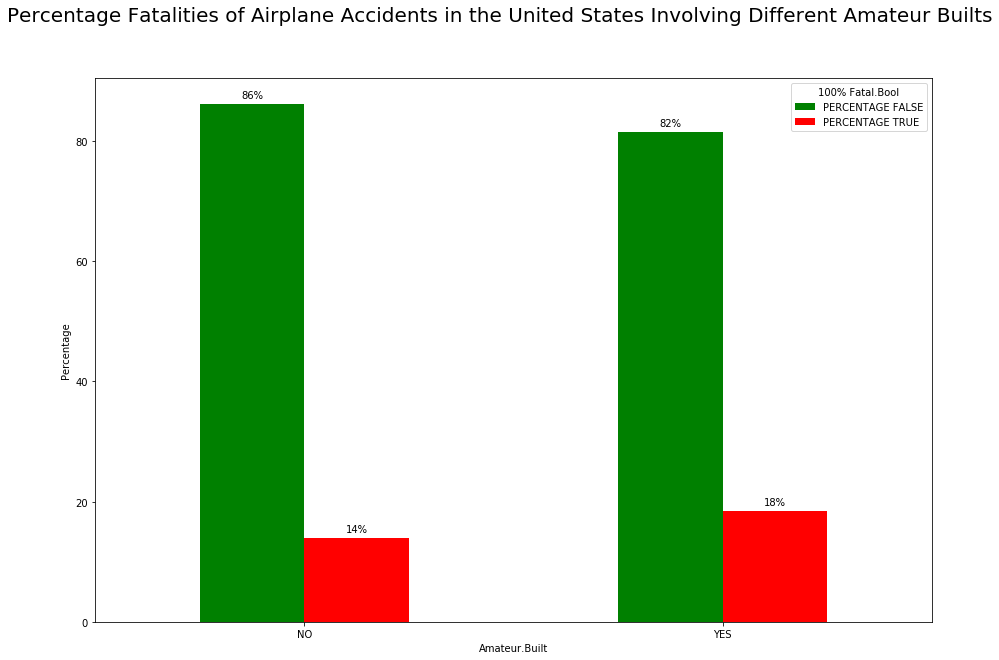

In [52]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct4.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Amateur.Built', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Percentage', fontsize = 10)
plt.suptitle('Percentage Fatalities of Airplane Accidents in the United States Involving Different Amateur Builts', fontsize = 20)
bars = ax.patches
half = int(len(bars)/2)
left_bars = bars[:half]
right_bars = bars[half:]
for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total = height_l + height_r
        ax.text(left.get_x() + left.get_width()/2., height_l + 1, '{0:.0%}'.format(height_l/total), ha = "center")
        ax.text(right.get_x() + right.get_width()/2., height_r + 1, '{0:.0%}'.format(height_r/total), ha = "center")

In [53]:
ct5 = pd.crosstab(df['Number.of.Engines'], df['100% Fatal.Bool'])
ct5

100% Fatal.Bool,FALSE,TRUE
Number.of.Engines,,
1.0,32390,4683
2.0,4799,1365
3.0,233,0
4.0,139,3


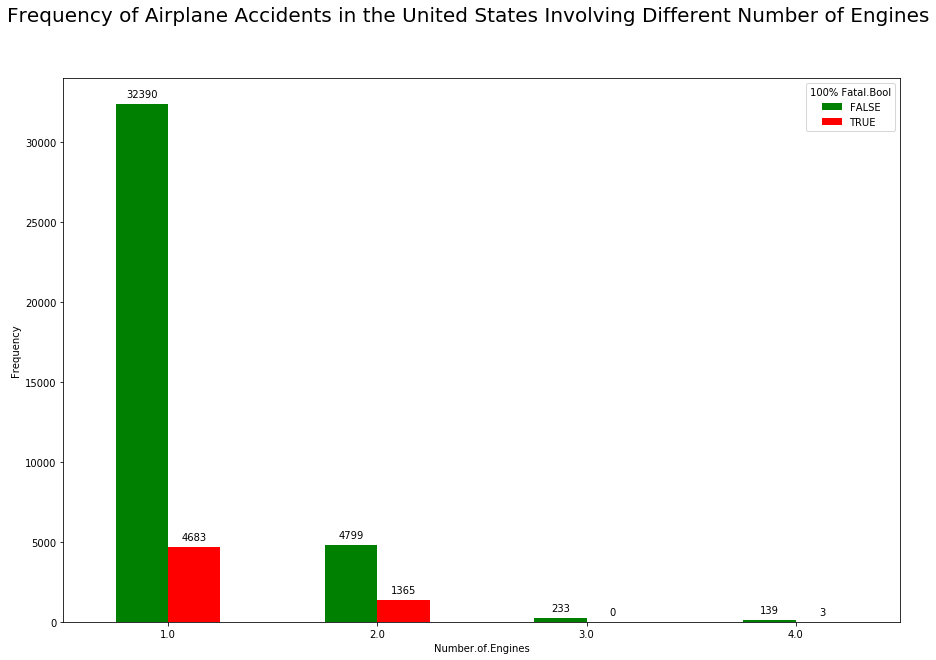

In [54]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct5.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Number.of.Engines', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Frequency', fontsize = 10)
plt.suptitle('Frequency of Airplane Accidents in the United States Involving Different Number of Engines', fontsize = 20)
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

In [55]:
TA = (ct5['FALSE'] + ct5['TRUE'])
ct5.insert(2,'TOTAL ACCIDENTS', TA)
ct5

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS
Number.of.Engines,,,
1.0,32390,4683,37073
2.0,4799,1365,6164
3.0,233,0,233
4.0,139,3,142


In [56]:
# Caclulating the Percentage Fatalities and Non-Fatalities for ct5
PercentageFalse = (100*ct5['FALSE']) / (ct5['TOTAL ACCIDENTS'])
ct5.insert(3, 'PERCENTAGE FALSE', PercentageFalse, True)
PercentageTrue = (100*ct5['TRUE']) / (ct5['TOTAL ACCIDENTS'])
ct5.insert(4, 'PERCENTAGE TRUE', PercentageTrue, True)
ct5 = ct5.round({'PERCENTAGE FALSE': 1, 'PERCENTAGE TRUE': 1})
ct5

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS,PERCENTAGE FALSE,PERCENTAGE TRUE
Number.of.Engines,,,,,
1.0,32390,4683,37073,87.4,12.6
2.0,4799,1365,6164,77.9,22.1
3.0,233,0,233,100.0,0.0
4.0,139,3,142,97.9,2.1


In [57]:
ct6 = ct5[['PERCENTAGE FALSE', 'PERCENTAGE TRUE']].copy()
ct6

100% Fatal.Bool,PERCENTAGE FALSE,PERCENTAGE TRUE
Number.of.Engines,,
1.0,87.4,12.6
2.0,77.9,22.1
3.0,100.0,0.0
4.0,97.9,2.1


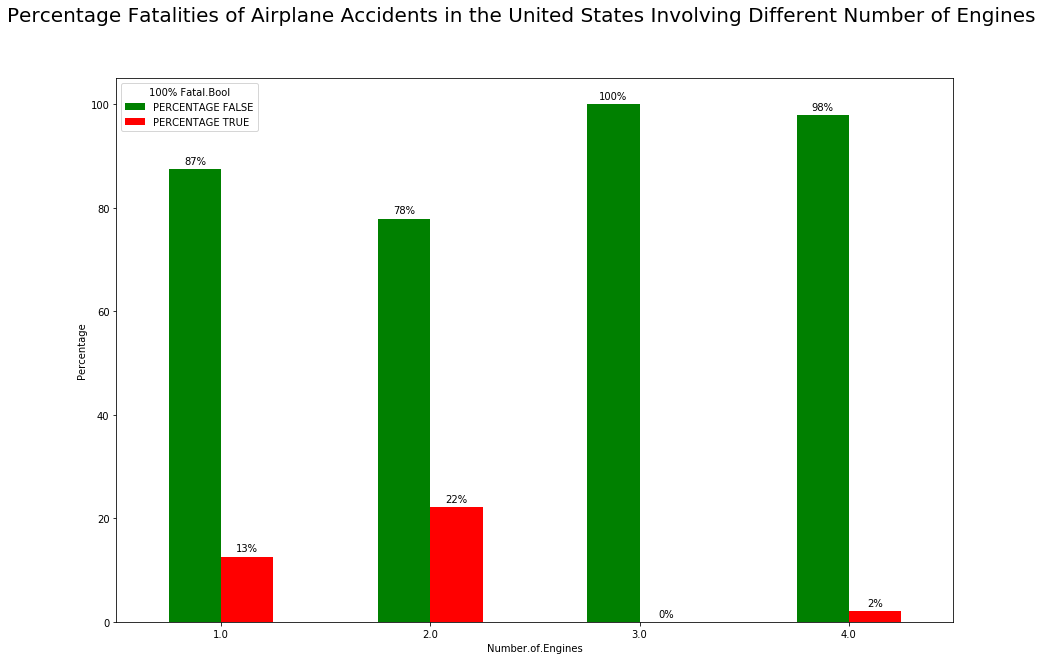

In [58]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct6.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Number.of.Engines', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Percentage', fontsize = 10)
plt.suptitle('Percentage Fatalities of Airplane Accidents in the United States Involving Different Number of Engines', fontsize = 20)
bars = ax.patches
half = int(len(bars)/2)
left_bars = bars[:half]
right_bars = bars[half:]
for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total = height_l + height_r
        ax.text(left.get_x() + left.get_width()/2., height_l + 1, '{0:.0%}'.format(height_l/total), ha = "center")
        ax.text(right.get_x() + right.get_width()/2., height_r + 1, '{0:.0%}'.format(height_r/total), ha = "center")

In [59]:
ct7 = pd.crosstab(df['Engine.Type'], df['100% Fatal.Bool'])
ct7

100% Fatal.Bool,FALSE,TRUE
Engine.Type,,
RECIPROCATING,35780,5790
TURBO FAN,842,21
TURBO JET,196,14
TURBO PROP,734,225
TURBO SHAFT,9,1


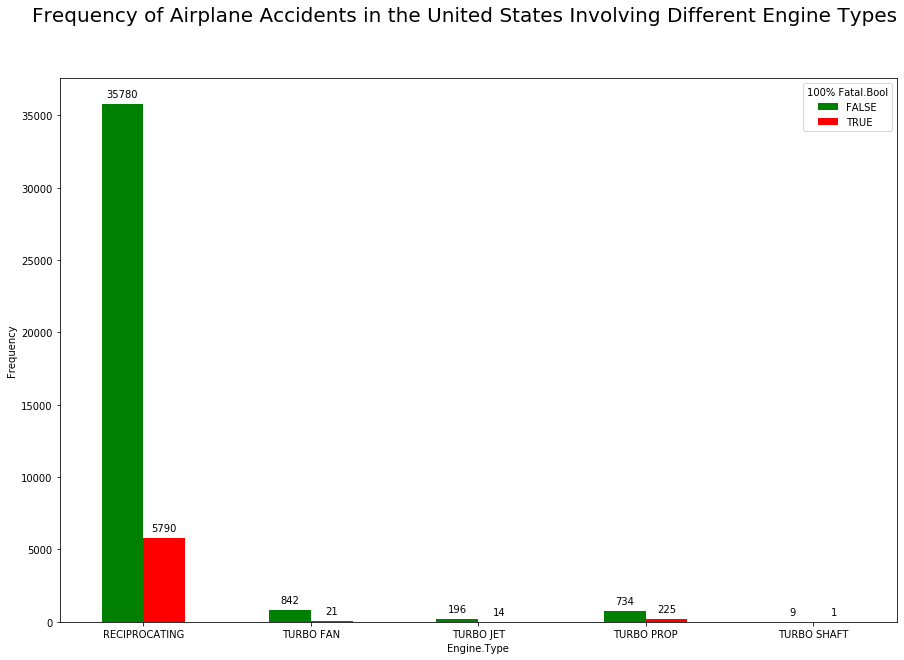

In [60]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct7.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Engine.Type', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Frequency', fontsize = 10)
plt.suptitle('Frequency of Airplane Accidents in the United States Involving Different Engine Types', fontsize = 20)
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

In [61]:
TA = (ct7['FALSE'] + ct7['TRUE'])
ct7.insert(2,'TOTAL ACCIDENTS', TA)
ct7

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS
Engine.Type,,,
RECIPROCATING,35780,5790,41570
TURBO FAN,842,21,863
TURBO JET,196,14,210
TURBO PROP,734,225,959
TURBO SHAFT,9,1,10


In [62]:
# Caclulating the Percentage Fatalities and Non-Fatalities for ct7
PercentageFalse = (100*ct7['FALSE']) / (ct7['TOTAL ACCIDENTS'])
ct7.insert(3, 'PERCENTAGE FALSE', PercentageFalse, True)
PercentageTrue = (100*ct7['TRUE']) / (ct7['TOTAL ACCIDENTS'])
ct7.insert(4, 'PERCENTAGE TRUE', PercentageTrue, True)
ct7 = ct7.round({'PERCENTAGE FALSE': 1, 'PERCENTAGE TRUE': 1})
ct7

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS,PERCENTAGE FALSE,PERCENTAGE TRUE
Engine.Type,,,,,
RECIPROCATING,35780,5790,41570,86.1,13.9
TURBO FAN,842,21,863,97.6,2.4
TURBO JET,196,14,210,93.3,6.7
TURBO PROP,734,225,959,76.5,23.5
TURBO SHAFT,9,1,10,90.0,10.0


In [63]:
ct8 = ct7[['PERCENTAGE FALSE', 'PERCENTAGE TRUE']].copy()
ct8

100% Fatal.Bool,PERCENTAGE FALSE,PERCENTAGE TRUE
Engine.Type,,
RECIPROCATING,86.1,13.9
TURBO FAN,97.6,2.4
TURBO JET,93.3,6.7
TURBO PROP,76.5,23.5
TURBO SHAFT,90.0,10.0


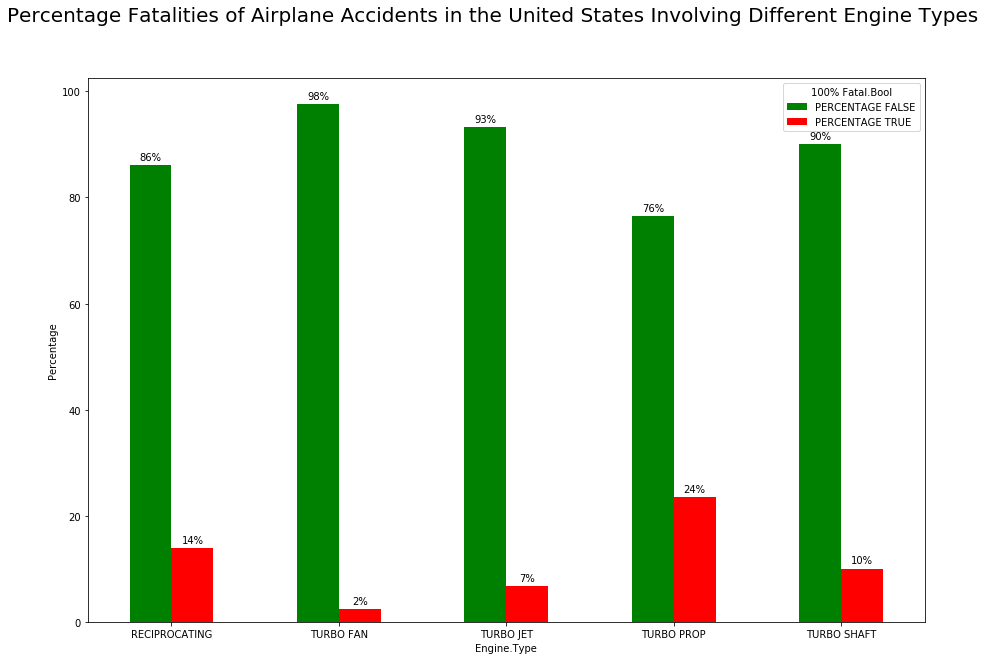

In [64]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct8.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Engine.Type', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Percentage', fontsize = 10)
plt.suptitle('Percentage Fatalities of Airplane Accidents in the United States Involving Different Engine Types', fontsize = 20)
bars = ax.patches
half = int(len(bars)/2)
left_bars = bars[:half]
right_bars = bars[half:]
for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total = height_l + height_r
        ax.text(left.get_x() + left.get_width()/2., height_l + 1, '{0:.0%}'.format(height_l/total), ha = "center")
        ax.text(right.get_x() + right.get_width()/2., height_r + 1, '{0:.0%}'.format(height_r/total), ha = "center")

In [65]:
ct9 = pd.crosstab(df['Weather.Condition'], df['100% Fatal.Bool'])
ct9

100% Fatal.Bool,FALSE,TRUE
Weather.Condition,,
IMC,1835,2105
VMC,35726,3946


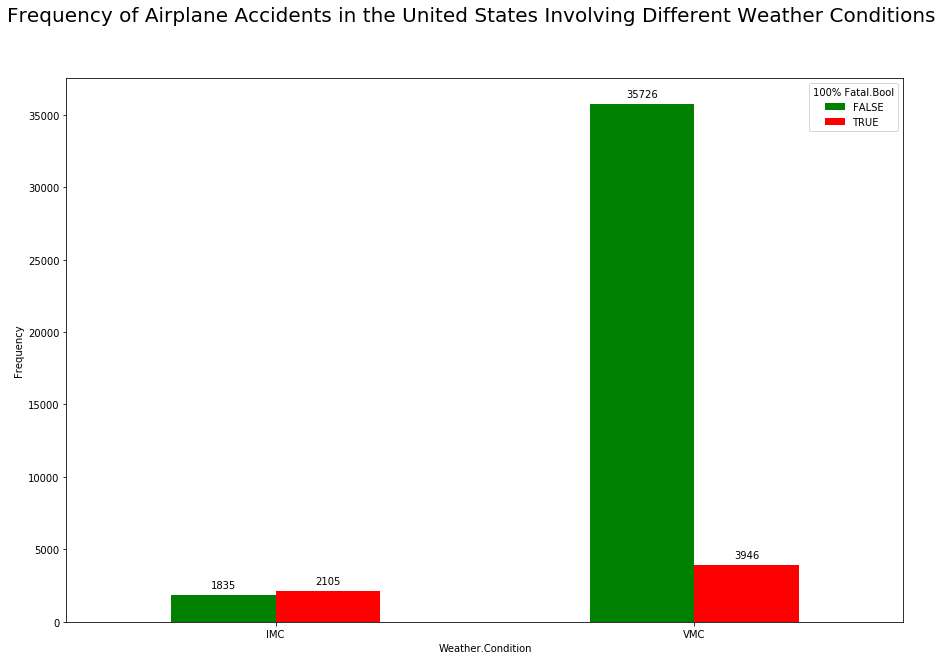

In [66]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct9.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Weather.Condition', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Frequency', fontsize = 10)
plt.suptitle('Frequency of Airplane Accidents in the United States Involving Different Weather Conditions', fontsize = 20)
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

In [67]:
TA = (ct9['FALSE'] + ct9['TRUE'])
ct9.insert(2,'TOTAL ACCIDENTS', TA)
ct9

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS
Weather.Condition,,,
IMC,1835,2105,3940
VMC,35726,3946,39672


In [68]:
# Caclulating the Percentage Fatalities and Non-Fatalities for ct9
PercentageFalse = (100*ct9['FALSE']) / (ct9['TOTAL ACCIDENTS'])
ct9.insert(3, 'PERCENTAGE FALSE', PercentageFalse, True)
PercentageTrue = (100*ct9['TRUE']) / (ct9['TOTAL ACCIDENTS'])
ct9.insert(4, 'PERCENTAGE TRUE', PercentageTrue, True)
ct9 = ct9.round({'PERCENTAGE FALSE': 1, 'PERCENTAGE TRUE': 1})
ct9

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS,PERCENTAGE FALSE,PERCENTAGE TRUE
Weather.Condition,,,,,
IMC,1835,2105,3940,46.6,53.4
VMC,35726,3946,39672,90.1,9.9


In [69]:
ct10 = ct9[['PERCENTAGE FALSE', 'PERCENTAGE TRUE']].copy()
ct10

100% Fatal.Bool,PERCENTAGE FALSE,PERCENTAGE TRUE
Weather.Condition,,
IMC,46.6,53.4
VMC,90.1,9.9


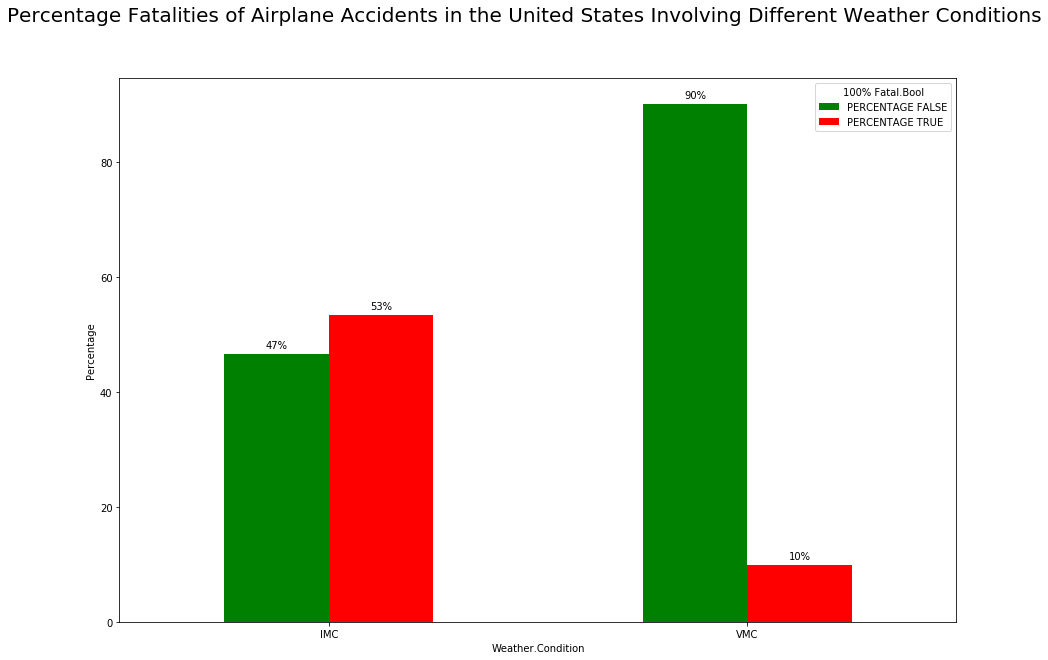

In [70]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct10.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Weather.Condition', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Percentage', fontsize = 10)
plt.suptitle('Percentage Fatalities of Airplane Accidents in the United States Involving Different Weather Conditions', fontsize = 20)
bars = ax.patches
half = int(len(bars)/2)
left_bars = bars[:half]
right_bars = bars[half:]
for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total = height_l + height_r
        ax.text(left.get_x() + left.get_width()/2., height_l + 1, '{0:.0%}'.format(height_l/total), ha = "center")
        ax.text(right.get_x() + right.get_width()/2., height_r + 1, '{0:.0%}'.format(height_r/total), ha = "center")

In [71]:
ct11 = pd.crosstab(df['Broad.Phase.of.Flight'], df['100% Fatal.Bool'])
ct11

100% Fatal.Bool,FALSE,TRUE
Broad.Phase.of.Flight,,
APPROACH,3969,946
CLIMB,1021,385
CRUISE,5012,1644
DESCENT,1089,320
GO-AROUND,1061,199
LANDING,13018,87
MANEUVERING,2212,1453
STANDING,619,23
TAKEOFF,7961,990


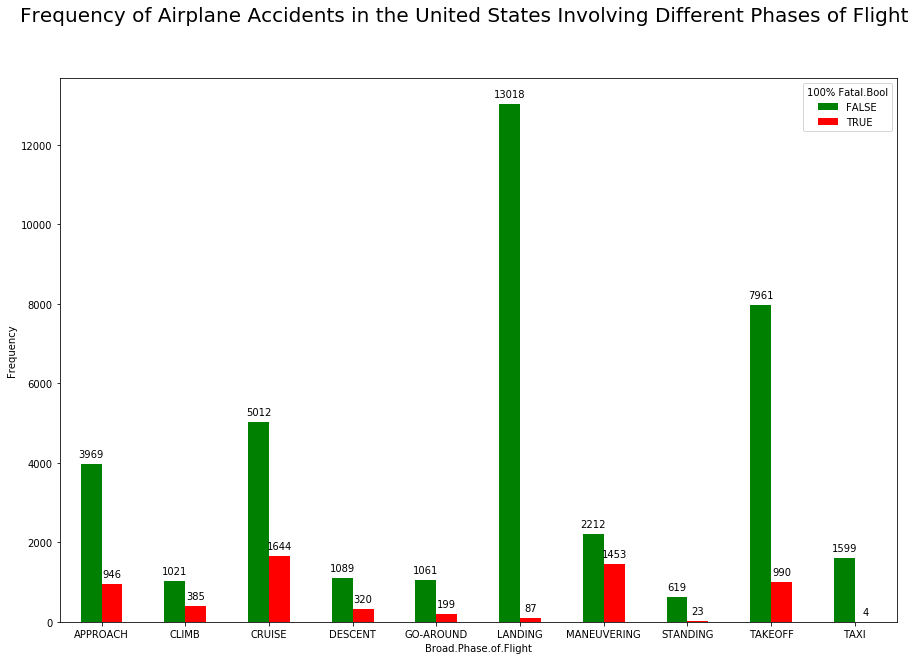

In [72]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct11.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Broad.Phase.of.Flight', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Frequency', fontsize = 10)
plt.suptitle('Frequency of Airplane Accidents in the United States Involving Different Phases of Flight', fontsize = 20)
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

In [73]:
TA = (ct11['FALSE'] + ct11['TRUE'])
ct11.insert(2,'TOTAL ACCIDENTS', TA)
ct11

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS
Broad.Phase.of.Flight,,,
APPROACH,3969,946,4915
CLIMB,1021,385,1406
CRUISE,5012,1644,6656
DESCENT,1089,320,1409
GO-AROUND,1061,199,1260
LANDING,13018,87,13105
MANEUVERING,2212,1453,3665
STANDING,619,23,642
TAKEOFF,7961,990,8951


In [74]:
# Caclulating the Percentage Fatalities and Non-Fatalities for ct11
PercentageFalse = (100*ct11['FALSE']) / (ct11['TOTAL ACCIDENTS'])
ct11.insert(3, 'PERCENTAGE FALSE', PercentageFalse, True)
PercentageTrue = (100*ct11['TRUE']) / (ct11['TOTAL ACCIDENTS'])
ct11.insert(4, 'PERCENTAGE TRUE', PercentageTrue, True)
ct11 = ct11.round({'PERCENTAGE FALSE': 1, 'PERCENTAGE TRUE': 1})
ct11

100% Fatal.Bool,FALSE,TRUE,TOTAL ACCIDENTS,PERCENTAGE FALSE,PERCENTAGE TRUE
Broad.Phase.of.Flight,,,,,
APPROACH,3969,946,4915,80.8,19.2
CLIMB,1021,385,1406,72.6,27.4
CRUISE,5012,1644,6656,75.3,24.7
DESCENT,1089,320,1409,77.3,22.7
GO-AROUND,1061,199,1260,84.2,15.8
LANDING,13018,87,13105,99.3,0.7
MANEUVERING,2212,1453,3665,60.4,39.6
STANDING,619,23,642,96.4,3.6
TAKEOFF,7961,990,8951,88.9,11.1


In [75]:
ct12 = ct11[['PERCENTAGE FALSE', 'PERCENTAGE TRUE']].copy()
ct12

100% Fatal.Bool,PERCENTAGE FALSE,PERCENTAGE TRUE
Broad.Phase.of.Flight,,
APPROACH,80.8,19.2
CLIMB,72.6,27.4
CRUISE,75.3,24.7
DESCENT,77.3,22.7
GO-AROUND,84.2,15.8
LANDING,99.3,0.7
MANEUVERING,60.4,39.6
STANDING,96.4,3.6
TAKEOFF,88.9,11.1


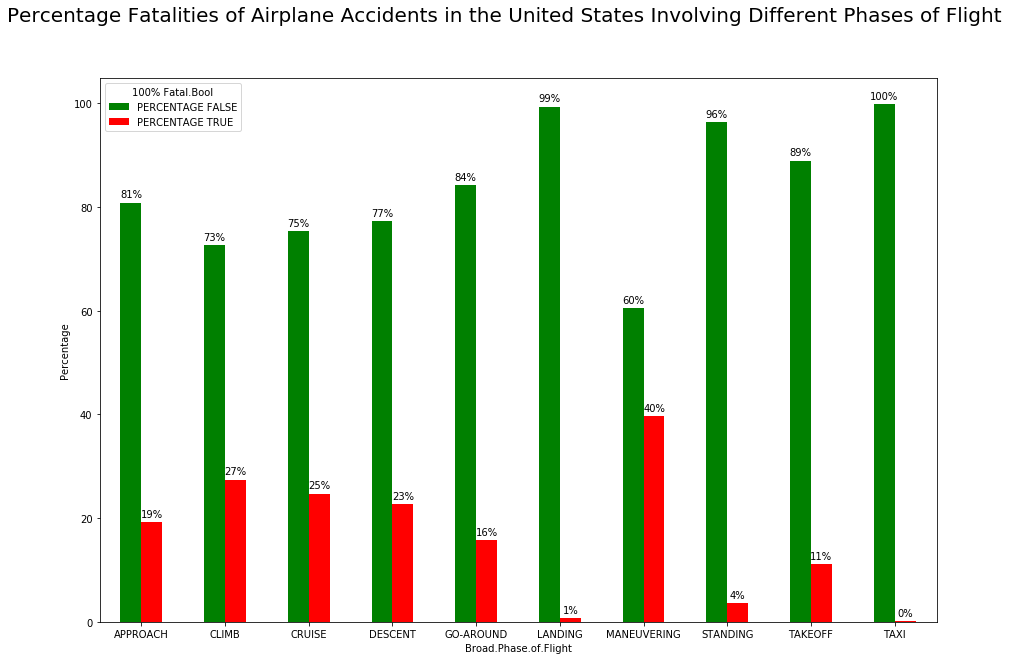

In [76]:
my_colors = list(islice(cycle(['g', 'r']), None, len(df)))
ax = ct12.plot.bar(figsize = [15,10], color = my_colors)
plt.xlabel('Broad.Phase.of.Flight', fontsize = 10)
plt.xticks(rotation = 'horizontal')
plt.ylabel('Percentage', fontsize = 10)
plt.suptitle('Percentage Fatalities of Airplane Accidents in the United States Involving Different Phases of Flight', fontsize = 20)
bars = ax.patches
half = int(len(bars)/2)
left_bars = bars[:half]
right_bars = bars[half:]
for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total = height_l + height_r
        ax.text(left.get_x() + left.get_width()/2., height_l + 1, '{0:.0%}'.format(height_l/total), ha = "center")
        ax.text(right.get_x() + right.get_width()/2., height_r + 1, '{0:.0%}'.format(height_r/total), ha = "center")

In [77]:
# Extracting the predictors we wish to use to predict 'FataL.Bool'
df2 = df[['Make', 'Number.of.Engines', 'Engine.Type', 'Weather.Condition', 'Broad.Phase.of.Flight']].copy()
df2

,Make,Number.of.Engines,Engine.Type,Weather.Condition,Broad.Phase.of.Flight
0,CESSNA,1,RECIPROCATING,VMC,TAKEOFF
1,MOONEY,1,RECIPROCATING,VMC,TAKEOFF
2,PIPER,2,TURBO PROP,IMC,TAKEOFF
3,CESSNA,1,RECIPROCATING,VMC,LANDING
4,CESSNA,1,RECIPROCATING,VMC,CRUISE
...,...,...,...,...,...
43607,CESSNA,1,RECIPROCATING,VMC,TAKEOFF
43608,CESSNA,2,RECIPROCATING,IMC,LANDING
43609,PIPER,1,RECIPROCATING,VMC,APPROACH
43610,BEECH,1,RECIPROCATING,VMC,LANDING


In [78]:
# Encoding the categorical variables for classification 
df2 = pd.get_dummies(df2)
df2

,Make_BEECH,Make_BOEING,Make_CESSNA,Make_MOONEY,Make_PIPER,Number.of.Engines_1.0,Number.of.Engines_2.0,Number.of.Engines_3.0,Number.of.Engines_4.0,Engine.Type_RECIPROCATING,...,Broad.Phase.of.Flight_APPROACH,Broad.Phase.of.Flight_CLIMB,Broad.Phase.of.Flight_CRUISE,Broad.Phase.of.Flight_DESCENT,Broad.Phase.of.Flight_GO-AROUND,Broad.Phase.of.Flight_LANDING,Broad.Phase.of.Flight_MANEUVERING,Broad.Phase.of.Flight_STANDING,Broad.Phase.of.Flight_TAKEOFF,Broad.Phase.of.Flight_TAXI
0,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43607,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
43608,0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
43609,0,0,0,0,1,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
43610,1,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


### Machine Learning - Classification Decision Tree
Using the Classification Decision Tree method to generate a model to predict if there are survivors from an accident. 
The dataset is split into train and test, and the predictors: Aircraft Make, Number of Engines, Engine Type, Weather Condition and Phase of Flight are used to predict the outcome, which is the Fatal Bool. 

These predictors could be easily obtained after an accident occurs by looking at the flight plans, which should have the information about the airplane. The weather condition can be known almost immediately from weather data and phase of flight can also be obtained from cross checking with flight plans or from Air Trafffic Control.  

The model is used on the train and test data to determine its classification Accuracy and Goodness of Fit. The Confusion Matrix is generated below as well.

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.8796355743067658

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.880491607814363



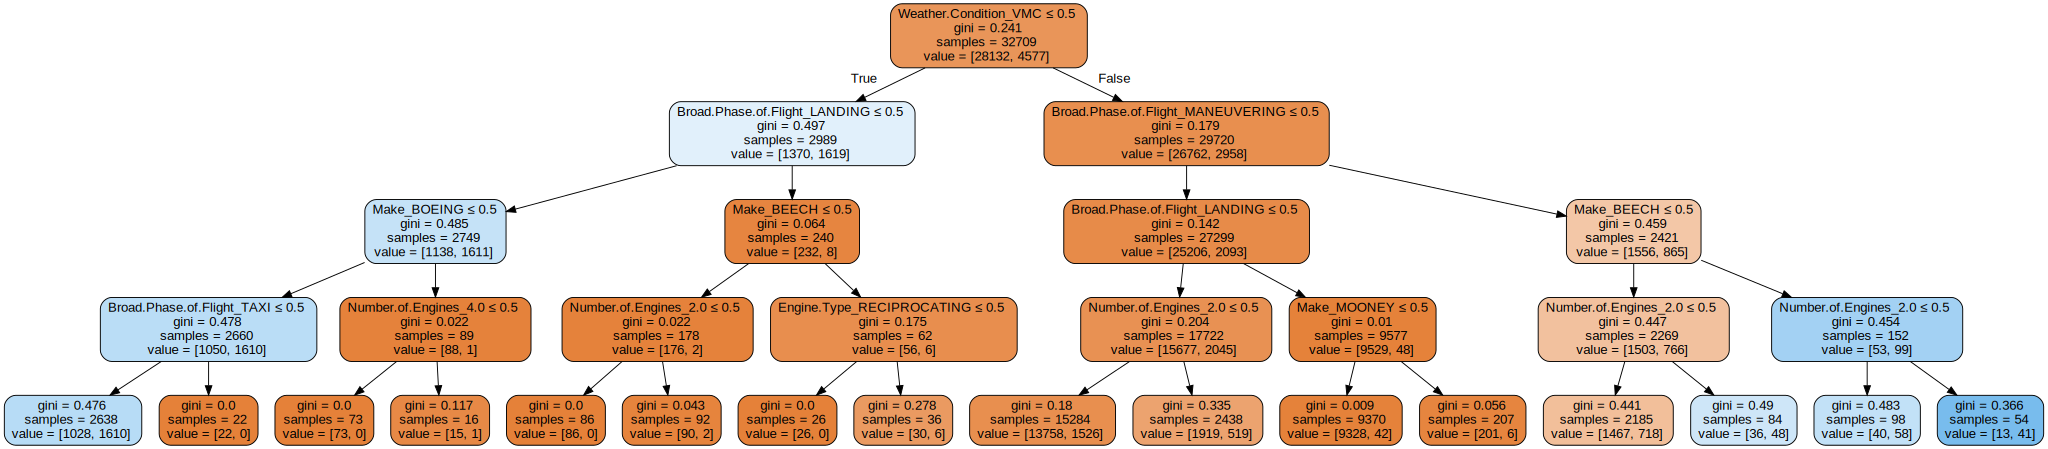

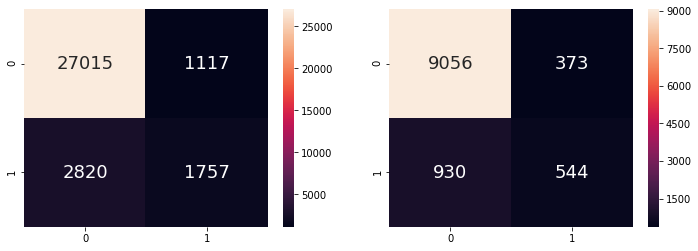

In [79]:
# Extract Response and Predictors
y = pd.DataFrame(df['100% Fatal.Bool'])
X = pd.DataFrame(df2) 

# Split the Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

# Decision Tree using Train Data
dectree = DecisionTreeClassifier(max_depth = 4)  # create the decision tree object
dectree.fit(X_train, y_train)                    # train the decision tree model

# Predict Response corresponding to Predictors
y_train_pred = dectree.predict(X_train)
y_test_pred = dectree.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(X_train, y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(X_test, y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sns.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])


# Plot the Decision Tree
treedot = export_graphviz(dectree,                                      # the model
                          feature_names = X_train.columns,              # the features 
                          out_file = None,                              # output file
                          filled = True,                                # node colors
                          rounded = True,                               # make pretty
                          special_characters = True)                    # postscript

graphviz.Source(treedot)

The False Positives in this context refers to the scenario where not everyone in the accident died, but it is still classified as a total fatality accident. This scenario could mislead authorities, making them think that there are no survivors where in fact there could be some survivors awaiting resue. Therefore this should be avoided and the false positives should be reduced to the minimum. 

In [80]:
# False Positive Rate for Train Set
tn,  fp, fn, tp = confusion_matrix(y_train, y_train_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
FPR = (fp/(tn+fp))
print('False Positive Rate =', FPR)

True Negatives: 27015
False Positives: 1117
False Negatives: 2820
True Positives: 1757
False Positive Rate = 0.03970567325465662


In [81]:
# False Positive Rate for Test Set
tn,  fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
FPR = (fp/(tn+fp))
print('False Positive Rate =', FPR)

True Negatives: 9056
False Positives: 373
False Negatives: 930
True Positives: 544
False Positive Rate = 0.03955880793297274


### Conclusion
The prediction model generated has an accuracy of around 88% for both train and test dataset. The False Positive Rate is also very low at around 3%. This is quite accurate and allows authorites to quickly predict and make decisions regarding search and rescue efforts for aviation accidents. 